# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV670"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv670')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv670/lv670-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV670,gene_band
0,SLC17A5,5.342333,6q13
1,IPMK,3.342822,10q21.1
2,PLAT,3.174483,8p11.21
3,KL,3.173938,13q13.1
4,INPP5J,3.098256,22q12.2
5,CFB,2.926680,6p21.33
6,ACSL3,2.689025,2q36.1
7,TINF2,2.674816,14q12
8,MAFB,2.566124,20q12
9,ATP1B1,2.520562,1q24.2


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 16:22:52,972 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 16:22:52,972 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR
1614,REACTOME_AMINO_ACID_AND_OLIGOPEPTIDE_SLC_TRANS...,670,0.885003,0.000201,0.001993


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP012167, SRP055569, SRP060416, SRP003901, SRP028336, SRP064464, SRP024268, SRP010483, SRP057196, SRP058773, SRP066834, SRP057248, SRP042161, SRP035268, SRP060355, SRP059732, SRP052056, SRP039552, SRP055810, SRP027530, SRP029262, SRP041751, SRP027364, SRP059509, SRP018853, SRP056330, SRP064735, SRP058722, SRP042620, SRP058667, SRP032812, SRP006575, SRP041094, SRP041826, SRP055512, SRP035387, SRP032789, SRP002487, SRP009862, SRP045276, SRP019936, SRP058237, SRP042184, SRP066356, SRP033135, SRP055153, SRP004837, SRP002326, SRP048222, SRP043434, SRP002628, SRP007412, SRP009266, SRP035477, SRP033401, SRP045352, SRP067701, SRP055513, SRP057244, SRP050499, SRP040243, SRP063834, SRP004847, SRP050534, SRP059950, SRP014856, SRP026042, SRP050087, SRP049713, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (67 != 69)
  warnings.warn(


In [12]:
lv_data.shape

(6016, 100)

In [13]:
lv_data.head()

patient             tissue    agent time cell type  \
project   run                                                            
SRP012167 SRR479052       1  Parathyroid tumor  Control  24h       NaN   
          SRR479053       1  Parathyroid tumor  Control  48h       NaN   
          SRR479054       1  Parathyroid tumor      DPN  24h       NaN   
          SRR479055       1  Parathyroid tumor      DPN  48h       NaN   
          SRR479056       1  Parathyroid tumor      OHT  24h       NaN   

                    tonsil donor facs gating pathology tumor stage  Sex  ...  \
project   run                                                            ...   
SRP012167 SRR479052          NaN         NaN       NaN         NaN  NaN  ...   
          SRR479053          NaN         NaN       NaN         NaN  NaN  ...   
          SRR479054          NaN         NaN       NaN         NaN  NaN  ...   
          SRR479055          NaN         NaN       NaN         NaN  NaN  ...   
          SRR479056          NaN         NaN       NaN         NaN  NaN  ...   

                    trimester antibody vender sources mice generation  \
project   run                                                           
SRP012167 SRR479052       NaN             NaN     NaN             NaN   
          SRR479053       NaN             NaN     NaN             NaN   
          SRR479054       NaN             NaN     NaN             NaN   
          SRR479055       NaN             NaN     NaN             NaN   
          SRR479056       NaN             NaN     NaN             NaN   

                    tumor treatment stage xenograft host tissue/treatment id  \
project   run                                                                  
SRP012167 SRR479052                   NaN            NaN                 NaN   
          SRR479053                   NaN            NaN                 NaN   
          SRR479054                   NaN            NaN                 NaN   
          SRR479055                   NaN            NaN                 NaN   
          SRR479056                   NaN            NaN                 NaN   

                    sequenced molecule transfection     LV670  
project   run                                                  
SRP012167 SRR479052                NaN          NaN  2.233387  
          SRR479053                NaN          NaN  1.938822  
          SRR479054                NaN          NaN  2.085001  
          SRR479055                NaN          NaN  1.840026  
          SRR479056                NaN          NaN  2.150169  

[5 rows x 100 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

agent                             0.487716
patient                           0.483013
time                              0.301415
tissue                            0.038326
human cell line                   0.026106
tnm                               0.014282
sources                           0.008780
strain                            0.008706
assigned cell type                0.007707
qc pass                           0.007707
cell count                        0.007707
ercc_mix                          0.007707
ercc_dilution                     0.007707
strain/background                 0.007144
age (years)                       0.007144
well number                       0.007080
reprogramming time point (day)    0.007080
pathology                         0.007030
tissue subtype                    0.006624
tag                               0.006624
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue            0.038326
tissue subtype    0.006624
cell type         0.003133
tissue type       0.001967
cell line         0.001572
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue",
    "tissue subtype",
    "cell type",
    "tissue type",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue tissue subtype cell type tissue type  \
project   run                                                                 
SRP012167 SRR479052  Parathyroid tumor            NaN       NaN         NaN   
          SRR479056  Parathyroid tumor            NaN       NaN         NaN   
          SRR479063  Parathyroid tumor            NaN       NaN         NaN   
          SRR479064  Parathyroid tumor            NaN       NaN         NaN   
          SRR479054  Parathyroid tumor            NaN       NaN         NaN   
          SRR479061  Parathyroid tumor            NaN       NaN         NaN   
          SRR479060  Parathyroid tumor            NaN       NaN         NaN   
          SRR479059  Parathyroid tumor            NaN       NaN         NaN   
          SRR479058  Parathyroid tumor            NaN       NaN         NaN   
          SRR479062  Parathyroid tumor            NaN       NaN         NaN   
          SRR479065  Parathyroid tumor            NaN       NaN         NaN   
          SRR479053  Parathyroid tumor            NaN       NaN         NaN   
          SRR479055  Parathyroid tumor            NaN       NaN         NaN   
          SRR479073  Parathyroid tumor            NaN       NaN         NaN   
          SRR479076  Parathyroid tumor            NaN       NaN         NaN   
          SRR479074  Parathyroid tumor            NaN       NaN         NaN   
          SRR479075  Parathyroid tumor            NaN       NaN         NaN   
          SRR479072  Parathyroid tumor            NaN       NaN         NaN   
          SRR479078  Parathyroid tumor            NaN       NaN         NaN   
          SRR479077  Parathyroid tumor            NaN       NaN         NaN   
          SRR479066  Parathyroid tumor            NaN       NaN         NaN   
          SRR479068  Parathyroid tumor            NaN       NaN         NaN   
          SRR479067  Parathyroid tumor            NaN       NaN         NaN   
          SRR479069  Parathyroid tumor            NaN       NaN         NaN   
          SRR479071  Parathyroid tumor            NaN       NaN         NaN   

                    cell line     LV670  
project   run                            
SRP012167 SRR479052       NaN  2.233387  
          SRR479056       NaN  2.150169  
          SRR479063       NaN  2.132878  
          SRR479064       NaN  2.131217  
          SRR479054       NaN  2.085001  
          SRR479061       NaN  2.080578  
          SRR479060       NaN  2.070496  
          SRR479059       NaN  2.051907  
          SRR479058       NaN  2.050110  
          SRR479062       NaN  2.024258  
          SRR479065       NaN  1.994884  
          SRR479053       NaN  1.938822  
          SRR479055       NaN  1.840026  
          SRR479073       NaN  1.514140  
          SRR479076       NaN  1.431019  
          SRR479074       NaN  1.383114  
          SRR479075       NaN  1.381273  
          SRR479072       NaN  1.329801  
          SRR479078       NaN  1.321474  
          SRR479077       NaN  1.315788  
          SRR479066       NaN  1.290341  
          SRR479068       NaN  1.272668  
          SRR479067       NaN  1.173552  
          SRR479069       NaN  1.157978  
          SRR479071       NaN  1.113477

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue tissue subtype  \
project   run                                               
SRP055569 SRR2019068                   NaN            NaN   
SRP060416 SRR2088346                   NaN            NaN   
SRP003901 SRR070179          kidney normal            NaN   
SRP028336 SRR945207                 kidney            NaN   
          SRR945206                 kidney            NaN   
SRP055569 SRR2019183                   NaN            NaN   
SRP064464 SRR2558168                   NaN            NaN   
SRP024268 SRR886387           renal pelvis            NaN   
SRP010483 SRR401816   islets of Langerhans            NaN   
SRP057196 SRR1974776                cortex            NaN   
SRP010483 SRR401824   islets of Langerhans            NaN   
SRP058773 SRR2042643                   NaN            NaN   
SRP066834 SRR2967832       Fetal neocortex            NaN   
          SRR2967829       Fetal neocortex            NaN   
SRP055569 SRR1821609                   NaN            NaN   
SRP057248 SRR1976386                   NaN            NaN   
SRP060416 SRR2088310                   NaN            NaN   
SRP057248 SRR1976385                   NaN            NaN   
SRP010483 SRR401818   islets of Langerhans            NaN   
SRP042161 SRR1294979                   NaN            NaN   
SRP003901 SRR070181          kidney normal            NaN   
SRP010483 SRR401822   islets of Langerhans            NaN   
SRP055569 SRR2018988                   NaN            NaN   
SRP064464 SRR2558164                   NaN            NaN   
SRP010483 SRR401817   islets of Langerhans            NaN   

                                                              cell type  \
project   run                                                             
SRP055569 SRR2019068                  WI-38 human lung fibroblast cells   
SRP060416 SRR2088346                       tonsil Innate lymphoid cells   
SRP003901 SRR070179                                                 NaN   
SRP028336 SRR945207                                                 NaN   
          SRR945206                                                 NaN   
SRP055569 SRR2019183  mixture of U87 human glioma cells and WI-38 hu...   
SRP064464 SRR2558168                                                NaN   
SRP024268 SRR886387                                                 NaN   
SRP010483 SRR401816                                                 NaN   
SRP057196 SRR1974776                                            neurons   
SRP010483 SRR401824                                                 NaN   
SRP058773 SRR2042643                                                NaN   
SRP066834 SRR2967832                                                NaN   
          SRR2967829                                                NaN   
SRP055569 SRR1821609  mixture of U87 human glioma cells and MCF10a h...   
SRP057248 SRR1976386                                                NaN   
SRP060416 SRR2088310                       tonsil Innate lymphoid cells   
SRP057248 SRR1976385                                                NaN   
SRP010483 SRR401818                                                 NaN   
SRP042161 SRR1294979                                       Glioblastoma   
SRP003901 SRR070181                                                 NaN   
SRP010483 SRR401822                                                 NaN   
SRP055569 SRR2018988                   MCF10a human breast cancer cells   
SRP064464 SRR2558164                                                NaN   
SRP010483 SRR401817                                                 NaN   

                     tissue type cell line     LV670  
project   run                                         
SRP055569 SRR2019068         NaN       NaN  1.014702  
SRP060416 SRR2088346         NaN       NaN  0.565719  
SRP003901 SRR070179          NaN       NaN  0.548228  
SRP028336 SRR945207          NaN       NaN  0.483208  
          SRR945206          NaN

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "tissue subtype",
    "cell type",
    "tissue type",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

tissue     LV670
project   run                                   
SRP012167 SRR479052  Parathyroid tumor  2.233387
          SRR479056  Parathyroid tumor  2.150169
          SRR479063  Parathyroid tumor  2.132878
          SRR479064  Parathyroid tumor  2.131217
          SRR479054  Parathyroid tumor  2.085001
          SRR479061  Parathyroid tumor  2.080578
          SRR479060  Parathyroid tumor  2.070496
          SRR479059  Parathyroid tumor  2.051907
          SRR479058  Parathyroid tumor  2.050110
          SRR479062  Parathyroid tumor  2.024258
          SRR479065  Parathyroid tumor  1.994884
          SRR479053  Parathyroid tumor  1.938822
          SRR479055  Parathyroid tumor  1.840026
          SRR479073  Parathyroid tumor  1.514140
          SRR479076  Parathyroid tumor  1.431019
          SRR479074  Parathyroid tumor  1.383114
          SRR479075  Parathyroid tumor  1.381273
          SRR479072  Parathyroid tumor  1.329801
          SRR479078  Parathyroid tumor  1.321474
          SRR479077  Parathyroid tumor  1.315788

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['Parathyroid tumor',
 'WI-38 human lung fibroblast cells',
 'tonsil Innate lymphoid cells',
 'kidney normal',
 'kidney']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

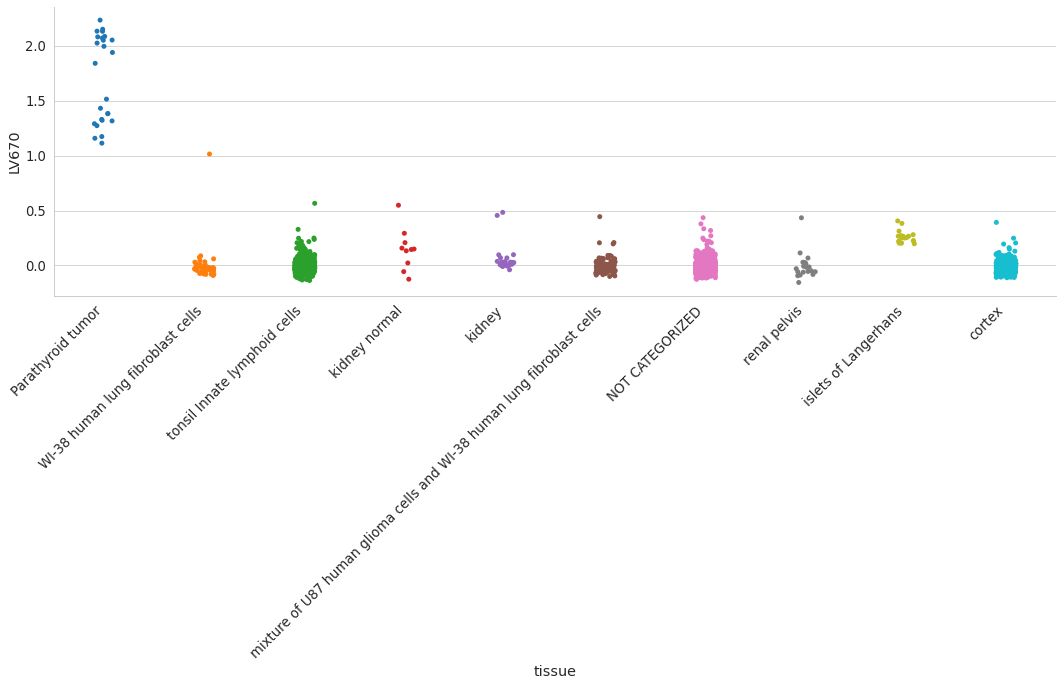

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Mesenc")
    ]
    display(_tmp.head(20))

cell type     LV582
project   run                                        
SRP012461 SRR490308  Mesenchymal Stem Cells  0.431175
          SRR490311  Mesenchymal Stem Cells  0.109218
          SRR490229  Mesenchymal Stem Cells  0.106094
          SRR490280  Mesenchymal Stem Cells  0.060764
          SRR490231  Mesenchymal Stem Cells  0.055113
          SRR490226  Mesenchymal Stem Cells  0.047083
          SRR490245  Mesenchymal Stem Cells  0.038019
          SRR490327  Mesenchymal Stem Cells  0.035258
          SRR490305  Mesenchymal Stem Cells  0.033120
          SRR490338  Mesenchymal Stem Cells  0.032719
          SRR490336  Mesenchymal Stem Cells  0.031067
          SRR490337  Mesenchymal Stem Cells  0.030776
          SRR490284  Mesenchymal Stem Cells  0.030576
          SRR490331  Mesenchymal Stem Cells  0.030554
          SRR490339  Mesenchymal Stem Cells  0.028162
          SRR490333  Mesenchymal Stem Cells  0.027978
          SRR490220  Mesenchymal Stem Cells  0.027498
          SRR490296  Mesenchymal Stem Cells  0.027087
          SRR490328  Mesenchymal Stem Cells  0.027043
          SRR490290  Mesenchymal Stem Cells  0.026657

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP012461"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell type       treatment day  \
project   run                                                     
SRP012461 SRR490465             Fibroblasts    Osteogenesis  d3   
          SRR490467             Fibroblasts    Osteogenesis  d3   
          SRR490464             Fibroblasts    Osteogenesis  d3   
          SRR490466             Fibroblasts    Osteogenesis  d3   
          SRR490308  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490311  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490229  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490280  Mesenchymal Stem Cells    Osteogenesis  d1   
          SRR490231  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490425             Fibroblasts    Adipogenesis  d7   
          SRR490456             Fibroblasts      Noninduced  d0   
          SRR490226  Mesenchymal Stem Cells    Adipogenesis  d2   
          SRR490449             Fibroblasts    Adipogenesis  d5   
          SRR490459             Fibroblasts      Noninduced  d0   
          SRR490452             Fibroblasts    Adipogenesis  d7   
          SRR490458             Fibroblasts      Noninduced  d0   
          SRR490514             Fibroblasts    Osteogenesis  d7   
          SRR490446             Fibroblasts    Adipogenesis  d4   
          SRR490571             Fibroblasts  Chondrogenesis  d5   
          SRR490511             Fibroblasts    Osteogenesis  d6   
          SRR490522             Fibroblasts  Chondrogenesis  d1   
          SRR490512             Fibroblasts    Osteogenesis  d7   
          SRR490427             Fibroblasts    Adipogenesis  d7   
          SRR490523             Fibroblasts  Chondrogenesis  d1   
          SRR490421             Fibroblasts    Adipogenesis  d6   
          SRR490517             Fibroblasts      Noninduced  d0   
          SRR490429             Fibroblasts      Noninduced  d0   
          SRR490509             Fibroblasts    Osteogenesis  d6   
          SRR490245  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490510             Fibroblasts    Osteogenesis  d6   
          SRR490445             Fibroblasts    Adipogenesis  d4   
          SRR490444             Fibroblasts    Adipogenesis  d4   
          SRR490327  Mesenchymal Stem Cells    Osteogenesis  d4   
          SRR490515             Fibroblasts    Osteogenesis  d7   
          SRR490447             Fibroblasts    Adipogenesis  d4   
          SRR490520             Fibroblasts  Chondrogenesis  d1   
          SRR490428             Fibroblasts      Noninduced  d0   
          SRR490418             Fibroblasts    Adipogenesis  d5   
          SRR490305  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490419             Fibroblasts    Adipogenesis  d5   
          SRR490485             Fibroblasts      Noninduced  d0   
          SRR490338  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490513             Fibroblasts    Osteogenesis  d7   
          SRR490499             Fibroblasts    Osteogenesis  d3   
          SRR490541             Fibroblasts  Chondrogenesis  d6   
          SRR490491             Fibroblasts    Osteogenesis  d1   
          SRR490497             Fibroblasts    Osteogenesis  d3   
          SRR490336  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490508             Fibroblasts    Osteogenesis  d6   
          SRR490337  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490519             Fibroblasts      Noninduced  d0   
          SRR490524             Fibroblasts  Chondrogenesis  d2   
          SRR490284  Mesenchymal Stem Cells    Osteogenesis  d2   
          SRR490457             Fibroblasts      Noninduced  d0   
          SRR490331  Mesenchymal Stem Cells    Osteogenesis  d5   
          SRR490516             Fibroblasts      Noninduced  d0   
          SRR490417             Fibroblasts    Adipogenesis  d5   
          SRR490498             Fibroblasts    Osteogenesis  d3   
          SRR4

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.